# 03 — Long-Document Preprocessing for Legal Summarization

This notebook converts the leakage-safe manifests from notebook 02 into quality-controlled datasets for **Qwen3-8B**. It creates sentence-aware chunks, aligns summary sentences through semantic subwindow embeddings, rejects weak or meaningless targets, formats examples with Qwen's native chat template, and exports SFT plus document-level evaluation files.

### Why this design?

Although Qwen3-8B supports a 32,768-token native context window, training at that full length is expensive. This notebook separates the **model context limit** from the **practical training sequence length**. The default `24gb` profile uses 4,096-token examples. Long chunks are divided into short semantic-alignment windows so the embedding model does not truncate most of a legal chunk. Low-confidence summary sentences are marked unmatched rather than forced into a chunk by position.

## 1. Configuration

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path(os.getenv(
    "LEGALMIND_PROJECT_ROOT",
    "/data2/user_data/sg57092c/LLM_finetune",
)).expanduser()
ZIP_PATH = Path(os.getenv(
    "LEGAL_DATASET_ZIP",
    str(PROJECT_ROOT / "dataset" / "dataset" / "legal_dataset.zip"),
)).expanduser()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "qwen3_8b_long_document"
REPORT_DIR = PROJECT_ROOT / "artifacts" / "qwen3_8b_long_document_preprocessing"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TOKENIZER_NAME = "Qwen/Qwen3-8B"
MODEL_CONTEXT_TOKENS = 32768  # Qwen3-8B native context capability

# Choose the preprocessing length to match the GPU plan for notebook 04.
TRAINING_PROFILE = os.getenv("LEGAL_TRAINING_PROFILE", "24gb").lower()
TRAINING_PROFILES = {
    # Recommended starting point for one 24 GB GPU with 4-bit QLoRA.
    "24gb": {
        "train_sequence_tokens": 4096,
        "max_input_tokens": 2800,
        "max_target_tokens": 1000,
        "prompt_reserve_tokens": 246,
        "chunk_overlap_tokens": 200,
    },
    # Use only when notebook 04 can train 8K sequences without OOM.
    "40gb_plus": {
        "train_sequence_tokens": 8192,
        "max_input_tokens": 6500,
        "max_target_tokens": 1200,
        "prompt_reserve_tokens": 392,
        "chunk_overlap_tokens": 256,
    },
}
if TRAINING_PROFILE not in TRAINING_PROFILES:
    raise ValueError(f"Unknown LEGAL_TRAINING_PROFILE={TRAINING_PROFILE!r}; choose 24gb or 40gb_plus")

profile = TRAINING_PROFILES[TRAINING_PROFILE]
TRAIN_SEQUENCE_TOKENS = profile["train_sequence_tokens"]
MAX_INPUT_TOKENS = profile["max_input_tokens"]
MAX_TARGET_TOKENS = profile["max_target_tokens"]
PROMPT_RESERVE_TOKENS = profile["prompt_reserve_tokens"]
CHUNK_OVERLAP_TOKENS = profile["chunk_overlap_tokens"]
ALIGNMENT_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
ALIGNMENT_WINDOW_TOKENS = 256
ALIGNMENT_WINDOW_OVERLAP_TOKENS = 64
MIN_SEMANTIC_SIMILARITY = 0.20
MIN_SEMANTIC_MATCH_RATE = 0.70
MIN_TARGET_TOKENS = 20
MIN_TARGET_WORDS = 8
MAX_TARGET_REJECTION_RATE = 0.05
MAX_TARGET_TRUNCATION_RATE = 0.10
RANDOM_SEED = 42

# Set to a small number such as 20 for a quick end-to-end smoke test.
MAX_CASES_PER_PARTITION = None

print(f"ZIP_PATH  : {ZIP_PATH}")
print(f"SPLIT_DIR : {SPLIT_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
assert TRAIN_SEQUENCE_TOKENS <= MODEL_CONTEXT_TOKENS
assert MAX_INPUT_TOKENS + MAX_TARGET_TOKENS + PROMPT_RESERVE_TOKENS <= TRAIN_SEQUENCE_TOKENS
print(f"Training profile: {TRAINING_PROFILE}")
print(
    f"Budget: input={MAX_INPUT_TOKENS}, target={MAX_TARGET_TOKENS}, "
    f"prompt reserve={PROMPT_RESERVE_TOKENS}, training sequence={TRAIN_SEQUENCE_TOKENS}"
)
print(f"Qwen native context capability: {MODEL_CONTEXT_TOKENS} tokens")

ZIP_PATH  : /data2/user_data/sg57092c/LLM_finetune/dataset/dataset/legal_dataset.zip
SPLIT_DIR : /data2/user_data/sg57092c/LLM_finetune/data/splits
OUTPUT_DIR: /data2/user_data/sg57092c/LLM_finetune/data/processed/qwen3_8b_long_document
Training profile: 24gb
Budget: input=2800, target=1000, prompt reserve=246, training sequence=4096
Qwen native context capability: 32768 tokens


## 2. Imports, authentication and models

This version requires `sentence-transformers`. Install it once with `pip install -U sentence-transformers`, then restart the kernel if the import is unavailable.

In [2]:
import hashlib
import json
import math
import re
import unicodedata
import zipfile
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
import torch
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import transformers
from packaging.version import Version
from transformers import AutoTokenizer

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_SEED)

if not ZIP_PATH.exists() or not zipfile.is_zipfile(ZIP_PATH):
    raise FileNotFoundError(f"Valid legal dataset ZIP not found: {ZIP_PATH}")

if Version(transformers.__version__) < Version("4.51.0"):
    raise RuntimeError(
        f"Qwen3 requires transformers>=4.51.0; found {transformers.__version__}. "
        "Upgrade with: pip install -U 'transformers>=4.51.0'"
    )

# Qwen3-8B is public. HF_TOKEN is optional, but loading it helps on rate-limited systems.
load_dotenv(PROJECT_ROOT / ".env")
hf_token = os.getenv("HF_TOKEN")
tokenizer = AutoTokenizer.from_pretrained(
    TOKENIZER_NAME,
    token=hf_token or None,
    use_fast=True,
)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if tokenizer.chat_template is None:
    raise ValueError("The selected tokenizer has no chat template.")

ALIGNMENT_DEVICE = os.getenv(
    "LEGAL_ALIGNMENT_DEVICE",
    "cuda" if torch.cuda.is_available() else "cpu",
)
alignment_model = SentenceTransformer(
    ALIGNMENT_MODEL_NAME,
    device=ALIGNMENT_DEVICE,
    token=hf_token or None,
)
alignment_tokenizer = alignment_model.tokenizer

print(f"Tokenizer loaded: {TOKENIZER_NAME} with transformers {transformers.__version__}")
print(f"EOS token: {tokenizer.eos_token!r} | pad token: {tokenizer.pad_token!r}")
print(
    f"Alignment model: {ALIGNMENT_MODEL_NAME} on {ALIGNMENT_DEVICE}; "
    f"model max length={alignment_model.max_seq_length}"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Tokenizer loaded: Qwen/Qwen3-8B with transformers 5.6.2
EOS token: '<|im_end|>' | pad token: '<|endoftext|>'
Alignment model: sentence-transformers/all-mpnet-base-v2 on cuda; model max length=384


## 3. Load final split manifests

In [3]:
MANIFEST_FILES = {
    "train": "train_manifest.jsonl",
    "validation": "validation_manifest.jsonl",
    "test_in_abs": "test_in_abs_manifest.jsonl",
    "test_in_ext_expert": "test_in_ext_expert_manifest.jsonl",
    "test_uk_abs": "test_uk_abs_manifest.jsonl",
}

manifests = {}
for partition, filename in MANIFEST_FILES.items():
    path = SPLIT_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing split manifest: {path}. Run notebook 02 first.")
    frame = pd.read_json(path, lines=True)
    if MAX_CASES_PER_PARTITION is not None:
        chosen_hashes = (
            frame[["judgment_hash"]]
            .drop_duplicates()
            .sample(n=min(MAX_CASES_PER_PARTITION, frame["judgment_hash"].nunique()), random_state=RANDOM_SEED)
            ["judgment_hash"]
        )
        frame = frame[frame["judgment_hash"].isin(chosen_hashes)].copy()
    manifests[partition] = frame

manifest_summary = pd.DataFrame([
    {
        "partition": name,
        "pairs": len(frame),
        "unique_cases": frame["judgment_hash"].nunique(),
        "datasets": ", ".join(sorted(frame["dataset"].unique())),
    }
    for name, frame in manifests.items()
])
display(manifest_summary)

,partition,pairs,unique_cases,datasets
0,train,6303,6303,IN-Abs
1,validation,700,700,IN-Abs
2,test_in_abs,100,100,IN-Abs
3,test_in_ext_expert,100,50,IN-Ext
4,test_uk_abs,99,99,UK-Abs


## 4. Conservative legal-text normalization

The cleaning intentionally avoids spelling correction because changing party names, citations, statute numbers or quoted language could alter legal meaning.

In [4]:
def decode_bytes(raw):
    for encoding in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return raw.decode(encoding), encoding
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace"), "utf-8-replacement"

def clean_legal_text(text):
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\x00", " ").replace("\r\n", "\n").replace("\r", "\n")
    # Join words broken only by a line-ending hyphen.
    text = re.sub(r"(?<=\w)-[ \t]*\n[ \t]*(?=\w)", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r" *\n *", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def normalized_sha256(text):
    canonical = re.sub(r"\s+", " ", text).strip().lower()
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()

def read_zip_text(zf, member_name):
    text, encoding = decode_bytes(zf.read(member_name))
    return clean_legal_text(text), encoding

def token_count(text):
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

## 5. Sentence-aware token chunking

In [5]:
SENTENCE_BOUNDARY = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9\[(])")

def split_legal_sentences(text):
    paragraphs = [p.strip() for p in re.split(r"\n{2,}", text) if p.strip()]
    sentences = []
    for paragraph in paragraphs:
        parts = [part.strip() for part in SENTENCE_BOUNDARY.split(paragraph) if part.strip()]
        sentences.extend(parts or [paragraph])
    return sentences or ([text.strip()] if text.strip() else [])

def hard_token_chunks(text, max_tokens, overlap_tokens):
    token_ids = tokenizer(text, add_special_tokens=False)["input_ids"]
    if not token_ids:
        return []
    step = max_tokens - overlap_tokens
    if step <= 0:
        raise ValueError("overlap_tokens must be smaller than max_tokens")
    chunks = []
    for start in range(0, len(token_ids), step):
        piece = token_ids[start:start + max_tokens]
        chunks.append(tokenizer.decode(piece, skip_special_tokens=True).strip())
        if start + max_tokens >= len(token_ids):
            break
    return [chunk for chunk in chunks if chunk]

def sentence_aware_chunks(
    text,
    max_tokens=MAX_INPUT_TOKENS,
    overlap_tokens=CHUNK_OVERLAP_TOKENS,
):
    sentences = split_legal_sentences(text)
    expanded_sentences = []
    for sentence in sentences:
        if token_count(sentence) <= max_tokens:
            expanded_sentences.append(sentence)
        else:
            expanded_sentences.extend(hard_token_chunks(sentence, max_tokens, overlap_tokens))

    chunks = []
    current = []
    for sentence in expanded_sentences:
        candidate = " ".join(current + [sentence]).strip()
        if current and token_count(candidate) > max_tokens:
            chunks.append(" ".join(current).strip())
            overlap_sentences = []
            overlap_size = 0
            for previous in reversed(current):
                previous_size = token_count(previous)
                if overlap_sentences and overlap_size + previous_size > overlap_tokens:
                    break
                if previous_size > overlap_tokens and overlap_sentences:
                    break
                overlap_sentences.insert(0, previous)
                overlap_size += previous_size
                if overlap_size >= overlap_tokens:
                    break
            current = overlap_sentences + [sentence]
        else:
            current.append(sentence)

    if current:
        chunks.append(" ".join(current).strip())

    bounded_chunks = []
    for chunk in chunks:
        if token_count(chunk) <= max_tokens:
            bounded_chunks.append(chunk)
        else:
            bounded_chunks.extend(hard_token_chunks(chunk, max_tokens, overlap_tokens))
    return bounded_chunks

# Small deterministic unit checks before processing thousands of cases.
assert sentence_aware_chunks("First sentence. Second sentence.", 20, 5)
assert all(token_count(c) <= MAX_INPUT_TOKENS for c in sentence_aware_chunks(
    "This is a legal sentence. " * 1000, MAX_INPUT_TOKENS, CHUNK_OVERLAP_TOKENS
))
print("Chunking smoke tests passed.")

Chunking smoke tests passed.


## 6. Semantic alignment and target-quality controls

Each long Qwen chunk is divided into short MPNet-token windows before embedding. Every meaningful reference-summary sentence is matched to its most similar window and therefore to the parent legal chunk. Sentences below the semantic threshold remain unmatched; there is no positional fallback. When a target exceeds its budget, the highest-confidence aligned sentences are selected and then restored to reference order.

In [6]:
ALPHA_WORD_PATTERN = re.compile(r"[A-Za-z][A-Za-z'’-]*")

def meaningful_summary_sentences(summary_text):
    accepted = []
    rejected = []
    for sentence_index, sentence in enumerate(split_legal_sentences(summary_text)):
        alpha_words = ALPHA_WORD_PATTERN.findall(sentence)
        if len(alpha_words) < 2:
            rejected.append({
                "summary_sentence_index": sentence_index,
                "sentence": sentence,
                "reason": "non_meaningful_summary_sentence",
            })
        else:
            accepted.append((sentence_index, sentence))
    return accepted, rejected

def make_alignment_windows(chunks):
    window_texts = []
    window_to_chunk = []
    step = ALIGNMENT_WINDOW_TOKENS - ALIGNMENT_WINDOW_OVERLAP_TOKENS
    if step <= 0:
        raise ValueError("Alignment overlap must be smaller than the window size.")

    for chunk_index, chunk in enumerate(chunks):
        ids = alignment_tokenizer(
            chunk, add_special_tokens=False, truncation=False
        )["input_ids"]
        for start in range(0, len(ids), step):
            piece_ids = ids[start:start + ALIGNMENT_WINDOW_TOKENS]
            piece = alignment_tokenizer.decode(
                piece_ids, skip_special_tokens=True
            ).strip()
            if piece:
                window_texts.append(piece)
                window_to_chunk.append(chunk_index)
            if start + ALIGNMENT_WINDOW_TOKENS >= len(ids):
                break
    return window_texts, window_to_chunk

def align_summary_to_chunks(
    summary_text, chunks, min_similarity=MIN_SEMANTIC_SIMILARITY
):
    summary_sentences, rejected_sentences = meaningful_summary_sentences(summary_text)
    assignments = {index: [] for index in range(len(chunks))}
    alignment_rows = []
    if not summary_sentences or not chunks:
        return assignments, alignment_rows, rejected_sentences

    window_texts, window_to_chunk = make_alignment_windows(chunks)
    if not window_texts:
        return assignments, alignment_rows, rejected_sentences

    sentence_texts = [sentence for _, sentence in summary_sentences]
    embeddings = alignment_model.encode(
        window_texts + sentence_texts,
        batch_size=64,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    window_embeddings = embeddings[:len(window_texts)]
    sentence_embeddings = embeddings[len(window_texts):]
    similarities = sentence_embeddings @ window_embeddings.T

    for row_index, (sentence_index, sentence) in enumerate(summary_sentences):
        best_window = int(np.argmax(similarities[row_index]))
        best_score = float(similarities[row_index, best_window])
        best_chunk = int(window_to_chunk[best_window])
        method = "semantic" if best_score >= min_similarity else "unmatched"
        if method == "semantic":
            assignments[best_chunk].append((sentence_index, sentence))
        alignment_rows.append({
            "summary_sentence_index": sentence_index,
            "chunk_index": best_chunk,
            "similarity": best_score,
            "method": method,
        })
    return assignments, alignment_rows, rejected_sentences

def fit_target_to_budget(assigned_sentences, alignment_info, max_target_tokens):
    score_by_index = {
        item["summary_sentence_index"]: item["similarity"]
        for item in alignment_info
        if item["method"] == "semantic"
    }
    ranked = sorted(
        assigned_sentences,
        key=lambda item: score_by_index.get(item[0], 0.0),
        reverse=True,
    )
    selected = []
    for sentence_index, sentence in ranked:
        candidate_rows = sorted(selected + [(sentence_index, sentence)])
        candidate = " ".join(text for _, text in candidate_rows).strip()
        if token_count(candidate) <= max_target_tokens:
            selected.append((sentence_index, sentence))

    truncated = len(selected) < len(assigned_sentences)
    if not selected and ranked:
        sentence_index, sentence = ranked[0]
        ids = tokenizer(sentence, add_special_tokens=False)["input_ids"][:max_target_tokens]
        selected = [(sentence_index, tokenizer.decode(ids, skip_special_tokens=True).strip())]
        truncated = True

    target = " ".join(text for _, text in sorted(selected)).strip()
    return target, truncated

def target_rejection_reason(target_text):
    stripped = target_text.strip()
    alpha_words = ALPHA_WORD_PATTERN.findall(stripped)
    if not stripped or stripped.isdigit():
        return "empty_or_numeric_target"
    if token_count(stripped) < MIN_TARGET_TOKENS:
        return "target_too_short_in_tokens"
    if len(alpha_words) < MIN_TARGET_WORDS:
        return "target_too_few_words"
    return None

test_assignments, test_alignment, test_rejected = align_summary_to_chunks(
    "The court dismissed the appeal. Costs were awarded.",
    ["The appeal was dismissed by the court.", "The successful party received costs."],
)
assert sum(len(v) for v in test_assignments.values()) == 2
assert target_rejection_reason("554") == "empty_or_numeric_target"
print("Semantic alignment and target-quality smoke tests passed.")

Semantic alignment and target-quality smoke tests passed.


## 7. Qwen chat-template construction and context-budget checks

In [7]:
SYSTEM_INSTRUCTION = (
    "Summarize only the supplied part of the legal judgment. Preserve material facts, "
    "statutes, legal reasoning and the court's decision when present. Do not add unsupported claims."
)

def build_user_message(jurisdiction, chunk_text, chunk_index, total_chunks):
    return (
        f"Jurisdiction: {jurisdiction}\n"
        f"Document part: {chunk_index + 1} of {total_chunks}\n\n"
        f"Legal text:\n{chunk_text}"
    )

def qwen_messages(jurisdiction, chunk_text, chunk_index, total_chunks, target_text=None):
    messages = [
        {"role": "system", "content": SYSTEM_INSTRUCTION},
        {
            "role": "user",
            "content": build_user_message(jurisdiction, chunk_text, chunk_index, total_chunks),
        },
    ]
    if target_text is not None:
        messages.append({"role": "assistant", "content": target_text})
    return messages

def build_prompt(jurisdiction, chunk_text, chunk_index, total_chunks):
    # Non-thinking mode avoids supervising or generating hidden reasoning for summarization.
    return tokenizer.apply_chat_template(
        qwen_messages(jurisdiction, chunk_text, chunk_index, total_chunks),
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def build_training_text(jurisdiction, chunk_text, chunk_index, total_chunks, target_text):
    return tokenizer.apply_chat_template(
        qwen_messages(jurisdiction, chunk_text, chunk_index, total_chunks, target_text),
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,
    )

def make_sft_record(row, chunk_text, chunk_index, total_chunks, target_text, alignment_info, target_truncated):
    prompt = build_prompt(row.jurisdiction, chunk_text, chunk_index, total_chunks)
    prompt_tokens = token_count(prompt)
    target_tokens = token_count(target_text)
    full_text = build_training_text(
        row.jurisdiction, chunk_text, chunk_index, total_chunks, target_text
    )
    total_tokens = token_count(full_text)
    if not full_text.startswith(prompt):
        raise ValueError("Qwen training text does not share the expected prompt prefix.")
    if total_tokens > TRAIN_SEQUENCE_TOKENS:
        raise ValueError(
            f"Training budget exceeded for {row.pair_id}, chunk {chunk_index}: "
            f"{total_tokens} > {TRAIN_SEQUENCE_TOKENS}"
        )
    return {
        "example_id": f"{row.pair_id}:chunk-{chunk_index:04d}",
        "pair_id": row.pair_id,
        "case_id": str(row.case_id),
        "dataset": row.dataset,
        "jurisdiction": row.jurisdiction,
        "assigned_split": row.assigned_split,
        "author": row.author,
        "judgment_hash": row.judgment_hash,
        "judgment_member": row.judgment_member,
        "summary_member": row.summary_member,
        "chunk_index": chunk_index,
        "total_chunks": total_chunks,
        "target_summary": target_text,
        "prompt": prompt,
        "text": full_text,
        "input_tokens": token_count(chunk_text),
        "prompt_tokens": prompt_tokens,
        "target_tokens": target_tokens,
        "total_tokens": total_tokens,
        "alignment_mean_similarity": float(np.mean([a["similarity"] for a in alignment_info])),
        "alignment_min_similarity": float(np.min([a["similarity"] for a in alignment_info])),
        "aligned_summary_sentences": int(len(alignment_info)),
        "target_truncated": bool(target_truncated),
    }

empty_prompt = build_prompt("India", "Example legal text.", 0, 1)
PROMPT_OVERHEAD_TOKENS = token_count(empty_prompt) - token_count("Example legal text.")
assert PROMPT_OVERHEAD_TOKENS <= PROMPT_RESERVE_TOKENS, (
    f"Increase PROMPT_RESERVE_TOKENS: measured {PROMPT_OVERHEAD_TOKENS}, "
    f"reserved {PROMPT_RESERVE_TOKENS}"
)
assert MAX_INPUT_TOKENS + MAX_TARGET_TOKENS + PROMPT_RESERVE_TOKENS <= TRAIN_SEQUENCE_TOKENS
print(f"Approximate prompt overhead: {PROMPT_OVERHEAD_TOKENS} tokens")
print("Configured input and target budgets fit inside the training sequence limit.")

Approximate prompt overhead: 68 tokens
Configured input and target budgets fit inside the training sequence limit.


## 8. Write SFT training and validation datasets

Only chunks receiving at least one confidently aligned reference sentence become supervised examples. Empty pairs, unmatched pairs, rejected summary sentences and rejected chunk targets are audited separately. The compact SFT JSONL avoids duplicate copies of each legal chunk while preserving prompt, full training text and lineage metadata.

In [8]:
def write_sft_dataset(manifest, output_path, zf):
    statistics = []
    skipped_pairs = []
    rejected_targets = []
    alignment_counts = Counter()
    alignment_scores = []
    rejected_summary_sentence_count = 0
    encoding_counts = Counter()
    with open(output_path, "w", encoding="utf-8") as output_file:
        grouped = manifest.groupby(["dataset", "judgment_member"], sort=True)
        for (_, judgment_member), group in tqdm(grouped, total=grouped.ngroups, desc=output_path.stem):
            judgment_text, judgment_encoding = read_zip_text(zf, judgment_member)
            encoding_counts[judgment_encoding] += 1
            chunks = sentence_aware_chunks(judgment_text, MAX_INPUT_TOKENS, CHUNK_OVERLAP_TOKENS)
            if not chunks:
                for row in group.itertuples(index=False):
                    skipped_pairs.append({
                        "pair_id": row.pair_id,
                        "judgment_hash": row.judgment_hash,
                        "partition": row.assigned_split,
                        "reason": "empty_judgment_after_cleaning",
                    })
                continue

            for row in group.itertuples(index=False):
                summary_text, summary_encoding = read_zip_text(zf, row.summary_member)
                encoding_counts[summary_encoding] += 1
                if not summary_text.strip():
                    skipped_pairs.append({
                        "pair_id": row.pair_id,
                        "judgment_hash": row.judgment_hash,
                        "partition": row.assigned_split,
                        "reason": "empty_summary_after_cleaning",
                    })
                    continue
                assignments, alignments, rejected_sentences = align_summary_to_chunks(
                    summary_text, chunks, MIN_SEMANTIC_SIMILARITY
                )
                rejected_summary_sentence_count += len(rejected_sentences)
                for alignment in alignments:
                    alignment_counts[alignment["method"]] += 1
                    alignment_scores.append(alignment["similarity"])
                alignment_by_chunk = {}
                for alignment in alignments:
                    if alignment["method"] == "semantic":
                        alignment_by_chunk.setdefault(alignment["chunk_index"], []).append(alignment)

                written_for_pair = 0
                for chunk_index, assigned in assignments.items():
                    if not assigned:
                        continue
                    target_text, target_truncated = fit_target_to_budget(
                        assigned, alignment_by_chunk[chunk_index], MAX_TARGET_TOKENS
                    )
                    rejection_reason = target_rejection_reason(target_text)
                    if rejection_reason is not None:
                        rejected_targets.append({
                            "pair_id": row.pair_id,
                            "judgment_hash": row.judgment_hash,
                            "chunk_index": chunk_index,
                            "target_tokens": token_count(target_text),
                            "target_preview": target_text[:160],
                            "reason": rejection_reason,
                        })
                        continue
                    record = make_sft_record(
                        row, chunks[chunk_index], chunk_index, len(chunks), target_text,
                        alignment_by_chunk[chunk_index], target_truncated,
                    )
                    output_file.write(json.dumps(record, ensure_ascii=False) + "\n")
                    statistics.append({
                        key: record[key]
                        for key in (
                            "example_id", "pair_id", "case_id", "dataset", "assigned_split", "judgment_hash",
                            "chunk_index", "total_chunks", "input_tokens", "target_tokens",
                            "total_tokens", "alignment_mean_similarity",
                            "alignment_min_similarity", "aligned_summary_sentences",
                            "target_truncated"
                        )
                    })
                    written_for_pair += 1

                if written_for_pair == 0:
                    skipped_pairs.append({
                        "pair_id": row.pair_id,
                        "judgment_hash": row.judgment_hash,
                        "partition": row.assigned_split,
                        "reason": "no_confident_valid_aligned_target",
                    })

    skipped_df = pd.DataFrame(
        skipped_pairs,
        columns=["pair_id", "judgment_hash", "partition", "reason"],
    )
    rejected_target_df = pd.DataFrame(
        rejected_targets,
        columns=[
            "pair_id", "judgment_hash", "chunk_index", "target_tokens",
            "target_preview", "reason",
        ],
    )
    semantic_matches = int(alignment_counts["semantic"])
    unmatched = int(alignment_counts["unmatched"])
    alignment_candidates = semantic_matches + unmatched
    alignment_report = {
        "semantic_matches": semantic_matches,
        "unmatched_sentences": unmatched,
        "semantic_match_rate": semantic_matches / max(1, alignment_candidates),
        "rejected_non_meaningful_summary_sentences": rejected_summary_sentence_count,
        "mean_best_similarity": float(np.mean(alignment_scores)) if alignment_scores else 0.0,
        "p10_best_similarity": float(np.quantile(alignment_scores, 0.10)) if alignment_scores else 0.0,
    }
    return (
        pd.DataFrame(statistics), dict(encoding_counts), skipped_df,
        rejected_target_df, alignment_report,
    )

with zipfile.ZipFile(ZIP_PATH) as zf:
    (train_stats, train_encodings, train_skipped, train_rejected_targets,
     train_alignment_report) = write_sft_dataset(
        manifests["train"], OUTPUT_DIR / "sft_train.jsonl", zf
    )
    (validation_stats, validation_encodings, validation_skipped, validation_rejected_targets,
     validation_alignment_report) = write_sft_dataset(
        manifests["validation"], OUTPUT_DIR / "sft_validation.jsonl", zf
    )

print(f"Training SFT examples  : {len(train_stats):,}")
print(f"Validation SFT examples: {len(validation_stats):,}")
print(f"Skipped training pairs  : {len(train_skipped):,}")
print(f"Skipped validation pairs: {len(validation_skipped):,}")
if len(train_skipped) or len(validation_skipped):
    display(pd.concat([train_skipped, validation_skipped], ignore_index=True))
display(pd.DataFrame([
    {"partition": "train", **train_alignment_report},
    {"partition": "validation", **validation_alignment_report},
]))
print(f"Rejected training chunk targets  : {len(train_rejected_targets):,}")
print(f"Rejected validation chunk targets: {len(validation_rejected_targets):,}")
display(pd.concat([
    train_stats.assign(partition="train"),
    validation_stats.assign(partition="validation"),
]).groupby("partition")[["input_tokens", "target_tokens", "total_tokens"]].describe().round(2))

sft_train:   0%|          | 0/6303 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2735 > 384). Running this sequence through the model will result in indexing errors


sft_validation:   0%|          | 0/700 [00:00<?, ?it/s]

Training SFT examples  : 15,333
Validation SFT examples: 1,730
Skipped training pairs  : 2
Skipped validation pairs: 0


,pair_id,judgment_hash,partition,reason
0,IN-Abs:299:reference,1bd826e7b44a19b12cf6daff4d43892cce6cf35567a90f6abf30d13f4c822144,train,empty_summary_after_cleaning
1,IN-Abs:4799:reference,4fb9fa50ca5562ada783cc2ee66f09ed78e6cdfd32c21c6966d8042097b31b63,train,empty_summary_after_cleaning


,partition,semantic_matches,unmatched_sentences,semantic_match_rate,rejected_non_meaningful_summary_sentences,mean_best_similarity,p10_best_similarity
0,train,179847,7495,0.959993,9723,0.595618,0.321505
1,validation,20102,868,0.958608,1115,0.593970,0.310630


Rejected training chunk targets  : 198
Rejected validation chunk targets: 24


input_tokens                                                  \
                  count     mean     std    min     25%     50%     75%   
partition                                                                 
train           15333.0  2303.24  739.08  124.0  1952.0  2752.0  2783.0   
validation       1730.0  2296.62  749.40  128.0  1893.0  2756.0  2785.0   

                   target_tokens                                             \
               max         count    mean     std   min    25%    50%    75%   
partition                                                                     
train       2800.0       15333.0  429.32  273.56  20.0  205.0  383.0  613.0   
validation  2800.0        1730.0  424.76  272.61  21.0  210.0  377.5  603.5   

                   total_tokens                                          \
               max        count     mean     std    min     25%     50%   
partition                                                                 
train       1000.0      15333.0  2802.70  859.20  239.0  2488.0  3079.0   
validation  1000.0       1730.0  2791.47  871.29  236.0  2428.0  3084.0   

                            
               75%     max  
partition                   
train       3358.0  3870.0  
validation  3355.5  3867.0

## 9. Build document-level inference chunks and references

Inference chunks are independent of reference summaries. References are written separately so evaluation cannot accidentally expose them to the model. IN-Ext produces 50 chunked cases and 100 reference records.

In [9]:
def write_inference_and_references(manifest, partition_name, zf):
    chunks_path = OUTPUT_DIR / f"{partition_name}_chunks.jsonl"
    references_path = OUTPUT_DIR / f"{partition_name}_references.jsonl"
    chunk_stats = []
    reference_stats = []

    with open(chunks_path, "w", encoding="utf-8") as chunks_file, open(
        references_path, "w", encoding="utf-8"
    ) as references_file:
        grouped = manifest.groupby(["dataset", "judgment_member"], sort=True)
        for (_, judgment_member), group in tqdm(grouped, total=grouped.ngroups, desc=partition_name):
            first = group.iloc[0]
            judgment_text, _ = read_zip_text(zf, judgment_member)
            chunks = sentence_aware_chunks(judgment_text, MAX_INPUT_TOKENS, CHUNK_OVERLAP_TOKENS)

            for chunk_index, chunk_text in enumerate(chunks):
                prompt = build_prompt(
                    first["jurisdiction"], chunk_text, chunk_index, len(chunks)
                )
                record = {
                    "chunk_id": f"{first['dataset']}:{first['case_id']}:chunk-{chunk_index:04d}",
                    "case_id": str(first["case_id"]),
                    "dataset": first["dataset"],
                    "jurisdiction": first["jurisdiction"],
                    "partition": partition_name,
                    "judgment_hash": first["judgment_hash"],
                    "judgment_member": judgment_member,
                    "chunk_index": chunk_index,
                    "total_chunks": len(chunks),
                    "input_text": chunk_text,
                    "messages": qwen_messages(
                        first["jurisdiction"], chunk_text, chunk_index, len(chunks)
                    ),
                    "prompt": prompt,
                    "input_tokens": token_count(chunk_text),
                    "prompt_tokens": token_count(prompt),
                }
                chunks_file.write(json.dumps(record, ensure_ascii=False) + "\n")
                chunk_stats.append({k: record[k] for k in (
                    "chunk_id", "case_id", "dataset", "partition", "judgment_hash",
                    "chunk_index", "total_chunks", "input_tokens", "prompt_tokens"
                )})

            for row in group.itertuples(index=False):
                summary_text, _ = read_zip_text(zf, row.summary_member)
                reference = {
                    "reference_id": row.pair_id,
                    "case_id": str(row.case_id),
                    "dataset": row.dataset,
                    "jurisdiction": row.jurisdiction,
                    "partition": partition_name,
                    "author": row.author,
                    "judgment_hash": row.judgment_hash,
                    "summary_hash": row.summary_hash,
                    "summary_member": row.summary_member,
                    "reference_summary": summary_text,
                    "reference_tokens": token_count(summary_text),
                }
                references_file.write(json.dumps(reference, ensure_ascii=False) + "\n")
                reference_stats.append({k: reference[k] for k in (
                    "reference_id", "case_id", "dataset", "partition",
                    "author", "reference_tokens"
                )})

    return pd.DataFrame(chunk_stats), pd.DataFrame(reference_stats)

evaluation_stats = {}
with zipfile.ZipFile(ZIP_PATH) as zf:
    for partition_name in ("validation", "test_in_abs", "test_in_ext_expert", "test_uk_abs"):
        chunk_stats, reference_stats = write_inference_and_references(
            manifests[partition_name], partition_name, zf
        )
        evaluation_stats[partition_name] = {
            "chunks": chunk_stats,
            "references": reference_stats,
        }

evaluation_output_summary = pd.DataFrame([
    {
        "partition": name,
        "unique_cases": values["chunks"]["judgment_hash"].nunique(),
        "chunks": len(values["chunks"]),
        "references": len(values["references"]),
        "mean_chunks_per_case": values["chunks"].groupby("case_id").size().mean(),
    }
    for name, values in evaluation_stats.items()
]).round(2)
display(evaluation_output_summary)

validation:   0%|          | 0/700 [00:00<?, ?it/s]

test_in_abs:   0%|          | 0/100 [00:00<?, ?it/s]

test_in_ext_expert:   0%|          | 0/50 [00:00<?, ?it/s]

test_uk_abs:   0%|          | 0/99 [00:00<?, ?it/s]

,partition,unique_cases,chunks,references,mean_chunks_per_case
0,validation,700,1822,700,2.60
1,test_in_abs,100,276,100,2.76
2,test_in_ext_expert,50,268,100,5.36
3,test_uk_abs,99,640,99,6.46


## 10. Quality gates

In [10]:
all_sft_stats = pd.concat([
    train_stats.assign(partition="train"),
    validation_stats.assign(partition="validation"),
], ignore_index=True)

all_skipped = pd.concat([train_skipped, validation_skipped], ignore_index=True)
all_rejected_targets = pd.concat(
    [train_rejected_targets, validation_rejected_targets], ignore_index=True
)
total_candidate_pairs = len(manifests["train"]) + len(manifests["validation"])
skipped_pair_rate = len(all_skipped) / max(1, total_candidate_pairs)
target_rejection_rate = len(all_rejected_targets) / max(
    1, len(all_sft_stats) + len(all_rejected_targets)
)
truncated_targets = int(all_sft_stats["target_truncated"].sum())
target_truncation_rate = truncated_targets / max(1, len(all_sft_stats))
semantic_matches = (
    train_alignment_report["semantic_matches"]
    + validation_alignment_report["semantic_matches"]
)
unmatched_sentences = (
    train_alignment_report["unmatched_sentences"]
    + validation_alignment_report["unmatched_sentences"]
)
semantic_match_rate = semantic_matches / max(1, semantic_matches + unmatched_sentences)
train_expected_pair_ids = set(manifests["train"]["pair_id"]) - set(train_skipped["pair_id"])
validation_expected_pair_ids = (
    set(manifests["validation"]["pair_id"]) - set(validation_skipped["pair_id"])
)

quality_gates = {
    "training_examples_created": len(train_stats) > 0,
    "validation_examples_created": len(validation_stats) > 0,
    "all_inputs_within_budget": bool((all_sft_stats["input_tokens"] <= MAX_INPUT_TOKENS).all()),
    "all_targets_within_budget": bool((all_sft_stats["target_tokens"] <= MAX_TARGET_TOKENS).all()),
    "all_targets_meet_minimum_length": bool((all_sft_stats["target_tokens"] >= MIN_TARGET_TOKENS).all()),
    "all_examples_within_training_sequence": bool((all_sft_stats["total_tokens"] <= TRAIN_SEQUENCE_TOKENS).all()),
    "training_sequence_within_model_context": TRAIN_SEQUENCE_TOKENS <= MODEL_CONTEXT_TOKENS,
    "all_non_skipped_train_pairs_represented": train_expected_pair_ids <= set(train_stats["pair_id"]),
    "all_non_skipped_validation_pairs_represented": validation_expected_pair_ids <= set(validation_stats["pair_id"]),
    "skipped_pair_rate_at_most_1pct": skipped_pair_rate <= 0.01,
    "semantic_match_rate_at_least_threshold": semantic_match_rate >= MIN_SEMANTIC_MATCH_RATE,
    "target_rejection_rate_within_limit": target_rejection_rate <= MAX_TARGET_REJECTION_RATE,
    "target_truncation_rate_within_limit": target_truncation_rate <= MAX_TARGET_TRUNCATION_RATE,
}
quality_gate_df = pd.DataFrame({
    "gate": list(quality_gates),
    "passed": list(quality_gates.values()),
})
display(quality_gate_df)
if not all(quality_gates.values()):
    raise AssertionError("One or more preprocessing quality gates failed.")

print(f"Semantic sentence match rate: {semantic_match_rate:.2%}")
print(f"Rejected chunk targets: {len(all_rejected_targets):,} ({target_rejection_rate:.2%})")
print(f"Examples with shortened targets: {truncated_targets:,} ({target_truncation_rate:.2%})")
print(f"Skipped unusable pairs: {len(all_skipped):,} ({skipped_pair_rate:.2%})")
print("PASS: model-ready datasets satisfy all configured context and coverage gates.")

,gate,passed
0,training_examples_created,True
1,validation_examples_created,True
2,all_inputs_within_budget,True
3,all_targets_within_budget,True
4,all_targets_meet_minimum_length,True
5,all_examples_within_training_sequence,True
6,training_sequence_within_model_context,True
7,all_non_skipped_train_pairs_represented,True
8,all_non_skipped_validation_pairs_represented,True
9,skipped_pair_rate_at_most_1pct,True


Semantic sentence match rate: 95.99%
Rejected chunk targets: 222 (1.28%)
Examples with shortened targets: 938 (5.50%)
Skipped unusable pairs: 2 (0.03%)
PASS: model-ready datasets satisfy all configured context and coverage gates.


## 11. Inspect examples and distributions


--- SAMPLE 1: IN-Abs:1:reference:chunk-0000 ---
Tokens: input=2785, target=204, total=3059
PROMPT PREVIEW: at the taxes in question fell clearly within the language of section 9 (1) (iv). The learned Attorney General, on the other hand, argued that although the taxes are assessed for the year the liability to pay them arises at the beginning 560 of each half year and unless a notice of demand is issued and a bill presented there is no liability to pay them and that till then no charge under section 212 of the Act could possibly arise and that the liability to pay being half yearly in advance, the charge is not an annual charge. It was also suggested that the taxes were a capital charge in the sense of the property being security for the payment.<|im_end|>
<|im_start|>assistant
<think>

</think>

 ...
TARGET PREVIEW: The charge created in respect of municipal property tax by section 212 of the City of Bombay Municipal Act, 1888, is an "annual charge not being a capital charge" within t

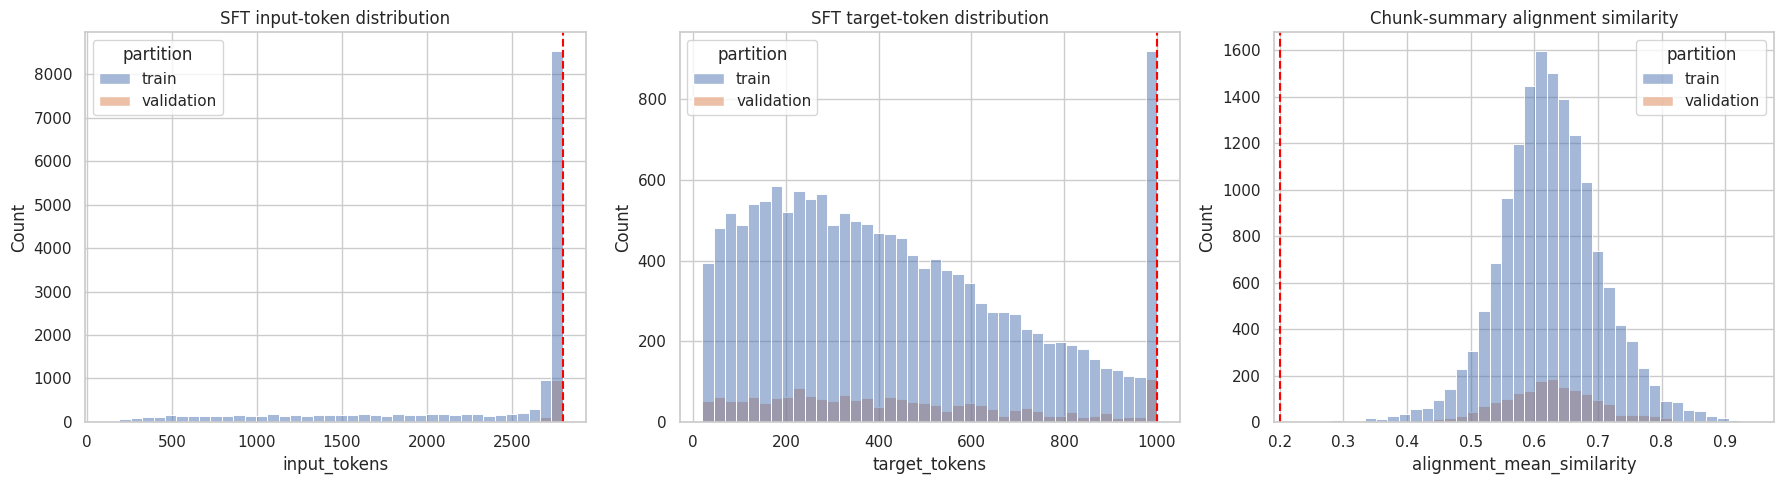

Saved figure: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_long_document_preprocessing/preprocessing_distributions.png


In [11]:
with open(OUTPUT_DIR / "sft_train.jsonl", "r", encoding="utf-8") as f:
    sample_records = [json.loads(next(f)) for _ in range(min(2, len(train_stats)))]

for index, record in enumerate(sample_records, start=1):
    print(f"\n--- SAMPLE {index}: {record['example_id']} ---")
    print(f"Tokens: input={record['input_tokens']}, target={record['target_tokens']}, total={record['total_tokens']}")
    print("PROMPT PREVIEW:", record["prompt"][-700:], "...")
    print("TARGET PREVIEW:", record["target_summary"][:500], "...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=all_sft_stats, x="input_tokens", hue="partition", bins=40, ax=axes[0])
axes[0].axvline(MAX_INPUT_TOKENS, color="red", linestyle="--")
axes[0].set_title("SFT input-token distribution")
sns.histplot(data=all_sft_stats, x="target_tokens", hue="partition", bins=40, ax=axes[1])
axes[1].axvline(MAX_TARGET_TOKENS, color="red", linestyle="--")
axes[1].set_title("SFT target-token distribution")
sns.histplot(data=all_sft_stats, x="alignment_mean_similarity", hue="partition", bins=40, ax=axes[2])
axes[2].axvline(MIN_SEMANTIC_SIMILARITY, color="red", linestyle="--")
axes[2].set_title("Chunk-summary alignment similarity")
plt.tight_layout()
figure_path = REPORT_DIR / "preprocessing_distributions.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure: {figure_path}")

## 12. Export compact reports and lineage metadata

In [12]:
train_stats.to_csv(REPORT_DIR / "sft_train_statistics.csv", index=False)
validation_stats.to_csv(REPORT_DIR / "sft_validation_statistics.csv", index=False)
all_skipped.to_csv(REPORT_DIR / "skipped_pairs.csv", index=False)
all_rejected_targets.to_csv(REPORT_DIR / "rejected_chunk_targets.csv", index=False)
alignment_summary_df = pd.DataFrame([
    {"partition": "train", **train_alignment_report},
    {"partition": "validation", **validation_alignment_report},
])
alignment_summary_df.to_csv(REPORT_DIR / "semantic_alignment_summary.csv", index=False)
quality_gate_df.to_csv(REPORT_DIR / "quality_gates.csv", index=False)
evaluation_output_summary.to_csv(REPORT_DIR / "evaluation_output_summary.csv", index=False)

report = {
    "source_zip": str(ZIP_PATH),
    "source_split_directory": str(SPLIT_DIR),
    "tokenizer": TOKENIZER_NAME,
    "model_context_tokens": MODEL_CONTEXT_TOKENS,
    "training_profile": TRAINING_PROFILE,
    "train_sequence_tokens": TRAIN_SEQUENCE_TOKENS,
    "prompt_reserve_tokens": PROMPT_RESERVE_TOKENS,
    "measured_prompt_overhead_tokens": PROMPT_OVERHEAD_TOKENS,
    "max_input_tokens": MAX_INPUT_TOKENS,
    "max_target_tokens": MAX_TARGET_TOKENS,
    "chunk_overlap_tokens": CHUNK_OVERLAP_TOKENS,
    "alignment_model": ALIGNMENT_MODEL_NAME,
    "alignment_window_tokens": ALIGNMENT_WINDOW_TOKENS,
    "alignment_window_overlap_tokens": ALIGNMENT_WINDOW_OVERLAP_TOKENS,
    "minimum_semantic_similarity": MIN_SEMANTIC_SIMILARITY,
    "minimum_semantic_match_rate": MIN_SEMANTIC_MATCH_RATE,
    "minimum_target_tokens": MIN_TARGET_TOKENS,
    "minimum_target_words": MIN_TARGET_WORDS,
    "random_seed": RANDOM_SEED,
    "max_cases_per_partition": MAX_CASES_PER_PARTITION,
    "train_sft_examples": int(len(train_stats)),
    "validation_sft_examples": int(len(validation_stats)),
    "train_unique_cases": int(train_stats["judgment_hash"].nunique()),
    "validation_unique_cases": int(validation_stats["judgment_hash"].nunique()),
    "skipped_pairs": int(len(all_skipped)),
    "skipped_pair_rate": float(skipped_pair_rate),
    "skipped_pair_reasons": all_skipped["reason"].value_counts().to_dict(),
    "rejected_chunk_targets": int(len(all_rejected_targets)),
    "target_rejection_rate": float(target_rejection_rate),
    "rejected_target_reasons": all_rejected_targets["reason"].value_counts().to_dict(),
    "semantic_matches": int(semantic_matches),
    "unmatched_summary_sentences": int(unmatched_sentences),
    "semantic_match_rate": float(semantic_match_rate),
    "training_alignment": train_alignment_report,
    "validation_alignment": validation_alignment_report,
    "truncated_target_examples": truncated_targets,
    "target_truncation_rate": float(target_truncation_rate),
    "quality_gates": quality_gates,
    "training_encodings": train_encodings,
    "validation_encodings": validation_encodings,
}
with open(REPORT_DIR / "preprocessing_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print(f"Processed datasets: {OUTPUT_DIR}")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name, f"({path.stat().st_size / 1024**2:.2f} MiB)")
print(f"Reports: {REPORT_DIR}")

Processed datasets: /data2/user_data/sg57092c/LLM_finetune/data/processed/qwen3_8b_long_document
 - sft_train.jsonl (382.25 MiB)
 - sft_validation.jsonl (42.98 MiB)
 - test_in_abs_chunks.jsonl (8.49 MiB)
 - test_in_abs_references.jsonl (0.55 MiB)
 - test_in_ext_expert_chunks.jsonl (7.58 MiB)
 - test_in_ext_expert_references.jsonl (0.94 MiB)
 - test_uk_abs_chunks.jsonl (23.04 MiB)
 - test_uk_abs_references.jsonl (0.67 MiB)
 - validation_chunks.jsonl (55.34 MiB)
 - validation_references.jsonl (3.60 MiB)
Reports: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_long_document_preprocessing


## 13. Handoff to notebook 04

`04_qwen3_qlora_finetuning.ipynb` should load `sft_train.jsonl` and `sft_validation.jsonl`, fine-tune `Qwen/Qwen3-8B` with 4-bit NF4 QLoRA, apply LoRA exactly once, and mask the first `prompt_tokens` labels so loss is calculated only on the assistant summary. Set the trainer's maximum sequence length to the exported `train_sequence_tokens`; do not automatically use Qwen's full 32K model context. The validation file should be supplied for checkpoint selection and early stopping.

For document-level evaluation, inference should summarize each `*_chunks.jsonl` record, group generated summaries by `case_id`, order them by `chunk_index`, and compare the combined result against the corresponding `*_references.jsonl` entries.